## **Step 1: Problem Definition**

# 🏦 Loan Approval & Credit Risk Prediction System

### 1. Problem Statement
Commercial banks require an automated risk evaluation engine to assess whether a loan applicant is likely to repay the loan (`loan_paid_back = 1`) or default (`loan_paid_back = 0`). This system solves this financial problem using supervised binary classification.

### 2. Dataset Overview
- **Dataset Source:** Kaggle Financial Loan Risk Prediction Repository
- **Total Records:** 593,994 rows
- **Raw Features:** 12 (11 predictors + 1 identifier)
- **Target Variable:** `loan_paid_back` (1: Fully Paid / Low Risk, 0: Defaulted / High Risk)

| Feature Name | Type | Description |
|---|---|---|
| `annual_income` | Numeric | Annual gross income of the applicant |
| `debt_to_income_ratio` | Numeric | Ratio of total monthly debt payments to gross monthly income |
| `credit_score` | Numeric | FICO credit score rating (300 - 850) |
| `loan_amount` | Numeric | Total principal loan amount applied for |
| `interest_rate` | Numeric | Interest percentage applied to the loan |
| `gender` | Categorical | Gender of the borrower (Male/Female/Other) |
| `marital_status` | Categorical | Marital status (Single/Married/Divorced) |
| `education_level` | Categorical | Academic qualification level |
| `employment_status` | Categorical | Employment sector/status |
| `loan_purpose` | Categorical | Purpose of applying for the facility |
| `grade_subgrade` | Categorical | Credit rating risk band (A1 - G5) |

# **Step 2: Imports & Environment Setup**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# to create a class in step 4 last
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, TransformerMixin
# more ----


# styles for graph
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
%matplotlib inline

## **Step 3: Load Data & Initial EDA**

Dataset Shape: (593994, 13)

--- Missing Values Count ---
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

Total Duplicate Records: 0


C:\Users\Lithira Jayanaka\AppData\Local\Temp\ipykernel_33012\4081722439.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_paid_back', palette='Set2')


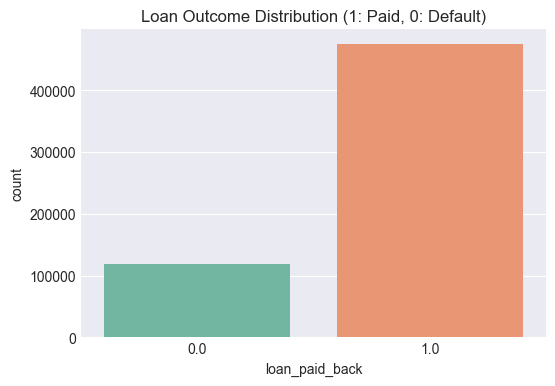

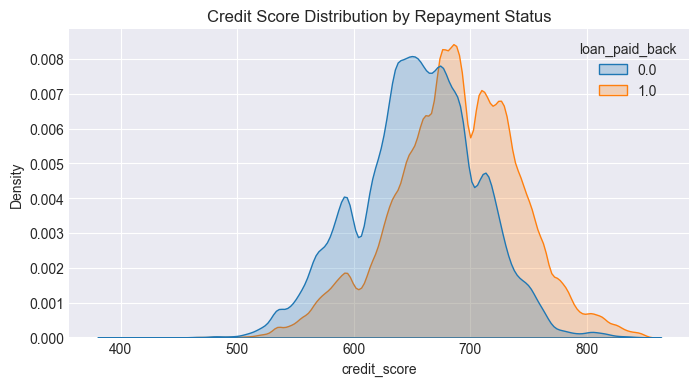

In [6]:
# Load dataset
file_path = Path('..') / 'data' / 'loan_risk_training_data_set.csv'
df = pd.read_csv(file_path)
print(f"Dataset Shape: {df.shape}")

# Checking Missing & Duplicates
print("\n--- Missing Values Count ---")
print(df.isnull().sum())
print("\nTotal Duplicate Records:", df.duplicated().sum())

# Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='loan_paid_back', palette='Set2')
plt.title("Loan Outcome Distribution (1: Paid, 0: Default)")
plt.show()

# Credit Score vs Default Risk Visualization
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df, x='credit_score', hue='loan_paid_back', common_norm=False, fill=True)
plt.title("Credit Score Distribution by Repayment Status")
plt.show()

In [7]:
df.info()
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


,count,mean,std,min,25%,50%,75%,max
id,593994.0,296996.500000,171471.442236,0.000,148498.250,296996.500,445494.750,593993.000
annual_income,593994.0,48212.202976,26711.942078,6002.430,27934.400,46557.680,60981.320,393381.740
debt_to_income_ratio,593994.0,0.120696,0.068573,0.011,0.072,0.096,0.156,0.627
credit_score,593994.0,680.916009,55.424956,395.000,646.000,682.000,719.000,849.000
loan_amount,593994.0,15020.297629,6926.530568,500.090,10279.620,15000.220,18858.580,48959.950
interest_rate,593994.0,12.356345,2.008959,3.200,10.990,12.370,13.680,20.990
loan_paid_back,593994.0,0.798820,0.400883,0.000,1.000,1.000,1.000,1.000


## **Step 4: Data Cleaning & Pre-check**

In [8]:
print("--- Missing Values Count per Column ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows Count ---")
print("Total duplicate rows:", df.duplicated().sum())

if 'id' in df.columns:
    print("Duplicates without ID column:", df.drop(columns=['id']).duplicated().sum())

--- Missing Values Count per Column ---
id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

--- Duplicate Rows Count ---
Total duplicate rows: 0
Duplicates without ID column: 0


In [9]:
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
else:
    print("No duplicates found to drop.")

if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print("Missing values removed.")
else:
    print("No missing values found.")

if 'id' in df.columns:
    df = df.drop(columns=['id'])
    print("Identifier column 'id' dropped.")

No duplicates found to drop.
No missing values found.
Identifier column 'id' dropped.


In [10]:
# 1. Removing Irrelevant Features (Technique 1)
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Custom Transformer to engineer domain features inside Pipeline
# This guarantees FastAPI will compute these dynamically without manual calculation!
class DomainFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()

        # Technique 2: Income to Loan Ratio (Debt Leverage)
        X_out['loan_to_income_ratio'] = X_out['loan_amount'] / (X_out['annual_income'] + 1.0)

        # Technique 3: Estimated Monthly Interest Cost (Feature Interaction)
        X_out['monthly_interest_cost'] = (X_out['loan_amount'] * (X_out['interest_rate'] / 100.0)) / 12.0

        # Technique 4: Credit Score Tier Binning (Binning Technique)
        # 0: Subprime (<620), 1: Near Prime (620-680), 2: Prime (>680)
        X_out['credit_tier'] = pd.cut(
            X_out['credit_score'],
            bins=[-np.inf, 620, 680, np.inf],
            labels=['Subprime', 'NearPrime', 'Prime']
        ).astype(str)

        return X_out

print("Feature Engineering logic constructed.")

Feature Engineering logic constructed.


## **Step 5: Feature and Label Separation**

In [11]:
# Separate Target Variable from Features
X = df.drop(columns=['loan_paid_back'])
y = df['loan_paid_back'].astype(int)

# Grouping numerical and categorical columns for the preprocessing pipeline
numeric_features = [
    'annual_income',
    'debt_to_income_ratio',
    'credit_score',
    'loan_amount',
    'interest_rate',
    'loan_to_income_ratio',
    'monthly_interest_cost'
]

categorical_features = [
    'gender',
    'marital_status',
    'education_level',
    'employment_status',
    'loan_purpose',
    'grade_subgrade',
    'credit_tier'
]

print(f"Features: {X.shape[1]} (Numeric: {len(numeric_features)}, Categorical: {len(categorical_features)})")

Features: 11 (Numeric: 7, Categorical: 7)


## **Step 6: Train / Test Split**

In [12]:

# Splitting the data while preserving the class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 475195 | Test size: 118799


## **Step 7: Build Preprocessing Pipeline & Model Architecture**

### Constructing the Machine Learning Pipeline
In this step, we bundle both the data pre-processing steps (scaling numerical values and encoding categorical text) and the predictive classifier into a single `scikit-learn` Pipeline.

**Why is this important?**
By orchestrating the workflow as a unified Pipeline, we can seamlessly export a single `.pkl` file. When deployed via FastAPI, this unified pipeline will automatically accept raw string/numeric inputs directly from the React frontend, dynamically transform them, and output the risk prediction without requiring redundant preprocessing code in the backend microservice.

In [13]:


# Configure preprocessor: StandardScaler for numeric, OneHotEncoder for categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Build the unified XGBoost Classifier Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

## **Step 8: Train the Model**


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix


# Candidate Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42),
    "XGBoost Classifier": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
}

comparison_results = []
trained_pipelines = {}

# Evaluate each model on an identical feature pipeline
for model_name, clf in models.items():
    print(f"Training {model_name}...")
    full_pipeline = Pipeline(steps=[
        ('engineer', DomainFeatureEngineer()),
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    full_pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = full_pipeline

    y_pred = full_pipeline.predict(X_test)
    y_proba = full_pipeline.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    comparison_results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4)
    })

print("Trained Successfully ....")

Training Logistic Regression...
Training Random Forest...
Training XGBoost Classifier...
Trained Successfully ....


## **Step 9: Model Evaluation & Performance Metrics**

In [15]:
# Performance Comparison Table
df_results = pd.DataFrame(comparison_results)
print("\n========== MODEL PERFORMANCE COMPARISON ==========")
print(df_results.to_string(index=False))


========== MODEL PERFORMANCE COMPARISON ==========
              Model  Accuracy  F1-Score  ROC-AUC
Logistic Regression    0.9007    0.9401   0.9103
      Random Forest    0.8996    0.9403   0.9030
 XGBoost Classifier    0.9048    0.9428   0.9200


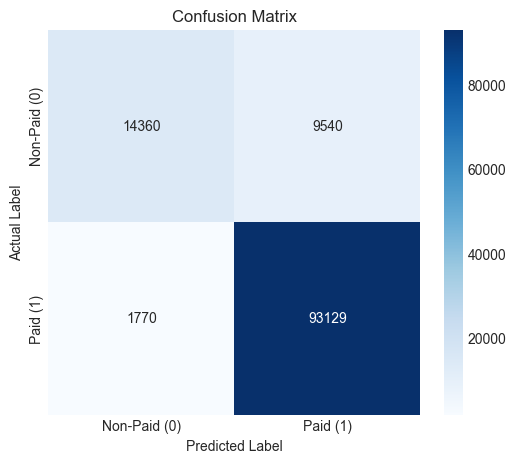

In [16]:
# Colab Code Cell 11
# Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Non-Paid (0)', 'Paid (1)'], yticklabels=['Non-Paid (0)', 'Paid (1)'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()